In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import optuna
import numpy as np
import sys, os, time
import torch
import torch.nn as nn
# import data, architecture
import optuna
# from torch.utils.data import random_split, DataLoader

mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

## Make test true vs predicted plots for multiple n sims

In [47]:
cosm_type = 'nwLH'
cosm_type_data_range =  'nwLH' #'nwLH_BSQ_combined' #'nwLH_BSQ_combined'
Pk_type = 'Pk'
all_n_sims = [1400]
n_sims_BSQ = 22000

k_max = 0.5
additional_extension = '_node_v2' #'_combined_weighted' #'_k_'+str(k_max)#'_combined_train_val_revisions'   '_fixed_ft_test'  '_node_v2'
mode = 'test'

In [48]:
if cosm_type_data_range == 'nwLH':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''

elif cosm_type_data_range == 'LH':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type_data_range == 'BSQ':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type_data_range == 'LC':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{local}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -300])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 300])
    params_ext = ''

elif cosm_type_data_range == 'EQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{equilateral}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -600])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 600])
    params_ext = ''

elif cosm_type_data_range == 'nwLH_BSQ_combined':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.00])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''


elif cosm_type_data_range == 'fR':
    num_params = 7
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$f_{R}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
    params_ext = '_lcdm'


300
300
true_vs_pred_Pk_nwLH_1400_nwLH_22000_BSQ_test_original.pdf


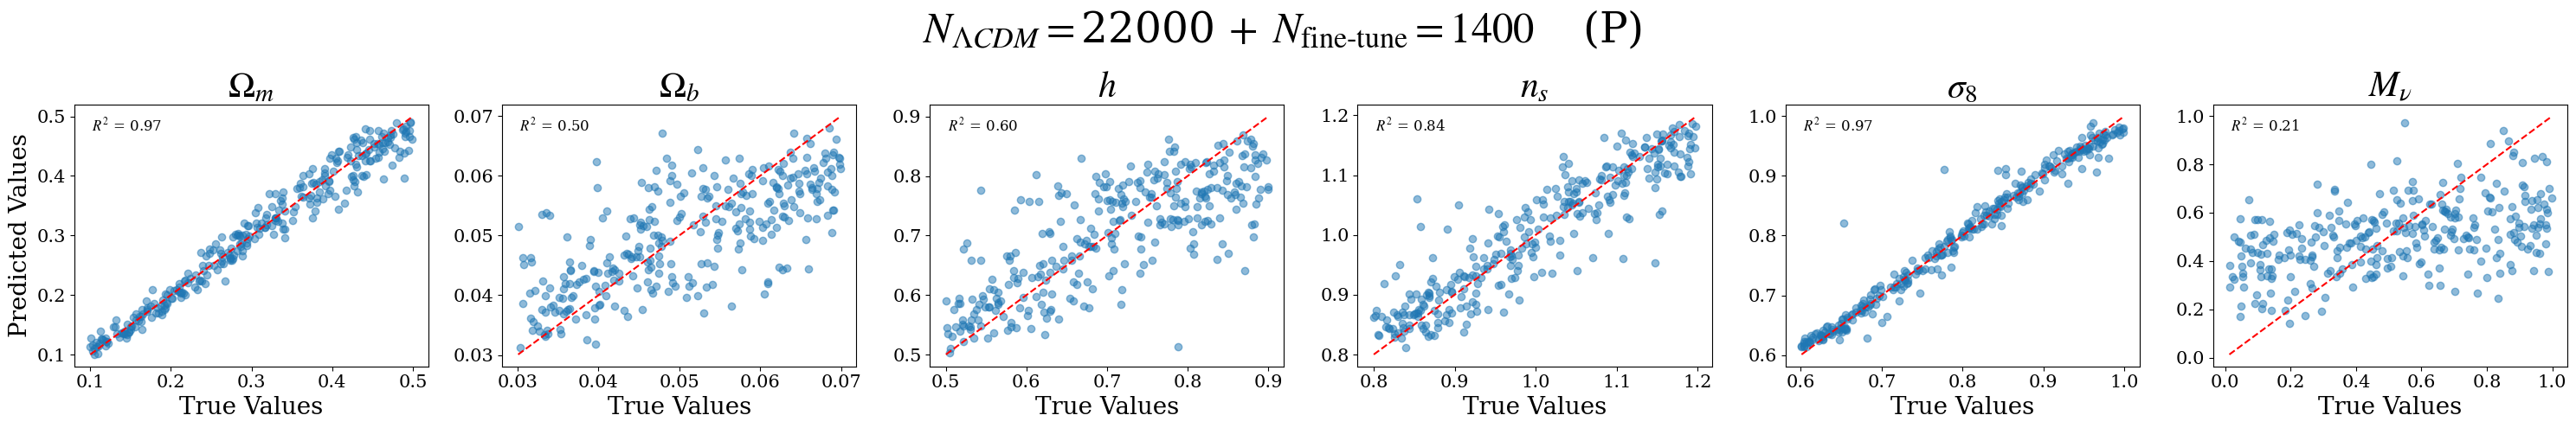

In [49]:
n_cols = num_params
n_rows = len(all_n_sims)
s = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*s, n_rows*s), sharex = False)
plt.tight_layout(rect=[0.12, 0, 1, 0.96])  # leave space left + for suptitle
fig.canvas.draw()  # <-- IMPORTANT: finalize positions

if n_rows == 1:
    axes = axes[None, :]

n_model = 0
for row, n_sims in enumerate(all_n_sims):

    if cosm_type == 'BSQ':
        name = 'transfer10_network1_'+str(n_sims)+'_'+cosm_type + additional_extension
    else:
        name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set

    test = np.loadtxt('../results/Results_'+mode+'_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name + params_ext+'_model'+str(n_model)+'.txt')
    test_true = test[:, :num_params]     # First half (true values)
    test_predicted = test[:, num_params:]  # Second half (predicted values)
    preds = test_predicted * (maximum - minimum) + minimum
    truths = test_true * (maximum - minimum) + minimum
    print (len(test_true))
    print(len(test_predicted))

    ax0 = axes[row, 0]
    bbox = ax0.get_position()      # in figure coordinates
    y_center = 0.5 * (bbox.y0 + bbox.y1)
    # fig.text(-0.02, y_center, rf'$N_{{\mathrm{{fine\!-\!tune}}}} = {n_sims}$', va='center', ha='left', fontsize=22, rotation=90)
    
    for col in range(num_params):
        ax = axes[row, col]
        ax.scatter(truths[:, col], preds[:, col], alpha=0.5)
        ax.plot([truths[:, col].min(), truths[:, col].max()], [truths[:, col].min(), truths[:, col].max()], 'r--')
        # ax.set_title(f'{dataset_name} - {param_names[col]}')
        # axes[2][col].set_xlabel('True Values')
        # axes[row][0].set_ylabel('Predicted Values')
        r2 = r2_score(truths[:, col], preds[:, col])
        mse = mean_squared_error(truths[:, col], preds[:, col])
        ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=15) # Adjust 15 to your liking
        
        axes[0][col].set_title(f'{param_names[col]}', fontsize = 30)
        axes[len(all_n_sims)-1][col].set_xlabel('True Values', fontsize = 20)
        axes[row][0].set_ylabel('Predicted Values', fontsize = 20)

plt.suptitle(r'$N_{\Lambda CDM} = $'+str(n_sims_BSQ)+r'$ \; + \; N_{\text{fine-tune}} = 1400 \;$ '+'  (P)', size = 35)
plt.tight_layout()
plt.savefig('true_vs_pred_'+Pk_type+'_'+cosm_type+'_'+str(n_sims)+'_nwLH_'+str(n_sims_BSQ)+'_BSQ_'+mode+'_original.pdf', format="pdf", bbox_inches="tight")
print('true_vs_pred_'+Pk_type+'_'+cosm_type+'_'+str(n_sims)+'_nwLH_'+str(n_sims_BSQ)+'_BSQ_'+mode+'_original.pdf')

plt.show()


## Same plots as above, but with normalized params

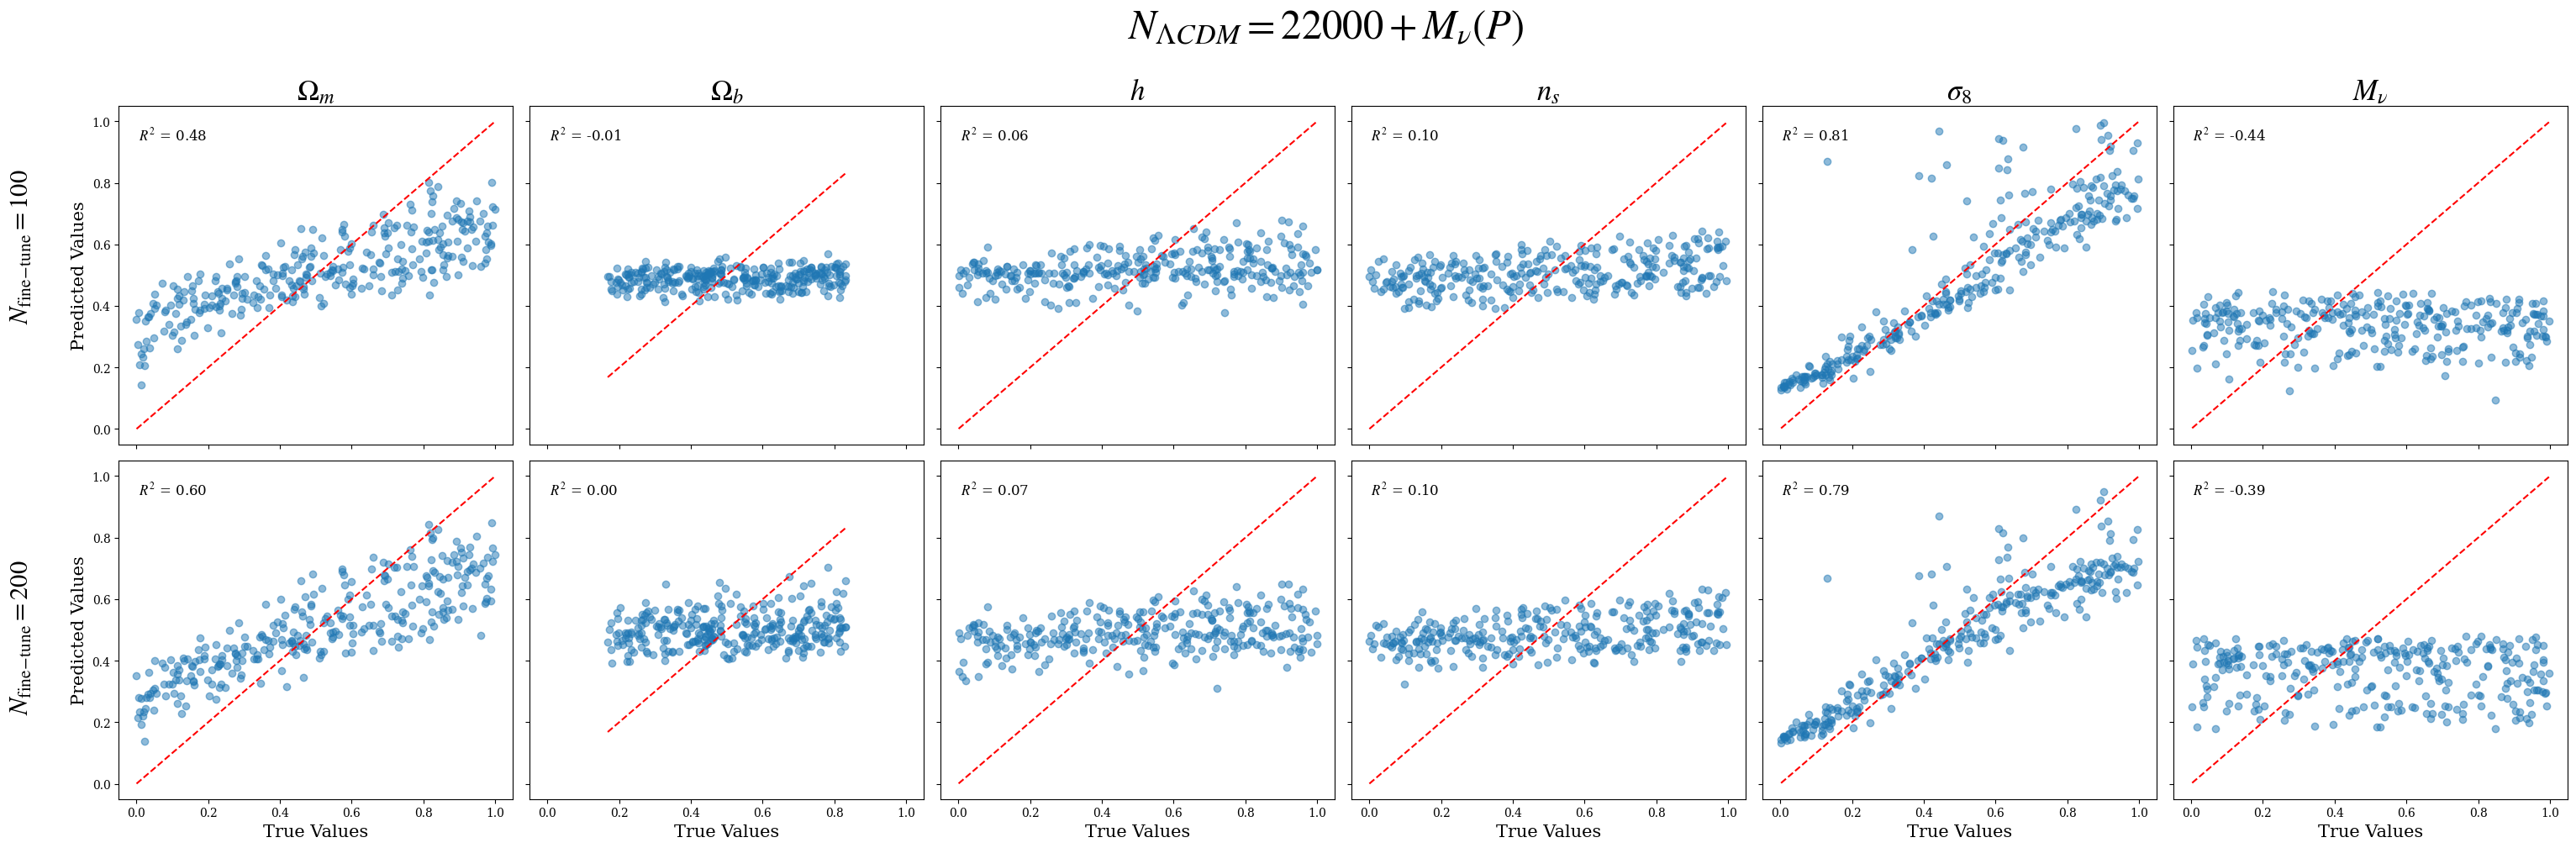

In [26]:
n_cols = num_params
n_rows = len(all_n_sims)
s = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*s, n_rows*s), sharex = True, sharey = True)
plt.tight_layout(rect=[0.12, 0, 1, 0.96])  # leave space left + for suptitle
fig.canvas.draw()  # <-- IMPORTANT: finalize positions

n_model = 0
for row, n_sims in enumerate(all_n_sims):

    if cosm_type == 'BSQ':
        name = 'transfer10_network1_'+str(n_sims)+'_'+cosm_type + additional_extension
    else:
        name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set

    test = np.loadtxt('../results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name + params_ext+'_model'+str(n_model)+'.txt')
    test_true = test[:, :num_params]     # First half (true values)
    test_predicted = test[:, num_params:]  # Second half (predicted values)
    preds = test_predicted * (maximum - minimum) + minimum
    truths = test_true * (maximum - minimum) + minimum

    ax0 = axes[row, 0]
    bbox = ax0.get_position()      # in figure coordinates
    y_center = 0.5 * (bbox.y0 + bbox.y1)
    fig.text(-0.02, y_center, rf'$N_{{\mathrm{{fine\!-\!tune}}}} = {n_sims}$', va='center', ha='left', fontsize=22, rotation=90)
    
    for col in range(num_params):
        ax = axes[row, col]
        ax.scatter(test_true[:, col], test_predicted[:, col], alpha=0.5)
        ax.plot([test_true[:, col].min(), test_true[:, col].max()], [test_true[:, col].min(), test_true[:, col].max()], 'r--')
        # ax.set_title(f'{dataset_name} - {param_names[col]}')
        # axes[2][col].set_xlabel('True Values')
        # axes[row][0].set_ylabel('Predicted Values')
        r2 = r2_score(test_true[:, col], test_predicted[:, col])
        mse = mean_squared_error(test_true[:, col], test_predicted[:, col])
        
        ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=12)
        axes[0][col].set_title(f'{param_names[col]}', fontsize = 25)
        axes[len(all_n_sims)-1][col].set_xlabel('True Values', fontsize = 15)
        axes[row][0].set_ylabel('Predicted Values', fontsize = 15)

plt.suptitle(r' $N_{\Lambda CDM} = 22000 + M_{\nu}(P)$', size = 35, y = 1.005)
plt.tight_layout()
# plt.savefig('transfer10_network2_Pk_1000_LC_32000_BSQ.png')
plt.show()


# Same as the above but make the rows different beyond LCDM cosmologies

## Make true vs predicted plots for train, valid and test at given n sims

In [19]:
cosm_type = 'BSQ'
Pk_type = 'Pk'
n_sims = 22000
n_sims_BSQ = 0
# additional_extension = '_fixed_ft_test'
additional_extension = '_node_v2'

In [20]:
if cosm_type == 'nwLH':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''

elif cosm_type == 'LH':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'BSQ':
    num_params = 5
    # num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'LC':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{local}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -300])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 300])
    params_ext = ''

elif cosm_type == 'EQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{equilateral}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -600])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 600])
    params_ext = ''

elif cosm_type == 'nwLH_BSQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''


elif cosm_type == 'fR':
    num_params = 7
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$f_{R}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
    params_ext = '_lcdm'


if cosm_type == 'BSQ':
    name = 'transfer10_network1_'+str(n_sims)+'_'+cosm_type + additional_extension
else:
    name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set
        


test = np.loadtxt('../results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
test_true = test[:, :num_params]     # First half (true values)
test_predicted = test[:, num_params:]  # Second half (predicted values)

train = np.loadtxt('../results/Results_train_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
train_true = train[:, :num_params]     # First half (true values)
train_predicted = train[:, num_params:]

valid = np.loadtxt('../results/Results_valid_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
valid_true = valid[:, :num_params]     # First half (true values)
valid_predicted = valid[:, num_params:]

# Reverse normalization for predictions
test_predicted = test_predicted * (maximum - minimum) + minimum
train_predicted = train_predicted * (maximum - minimum) + minimum
valid_predicted = valid_predicted * (maximum - minimum) + minimum

# Reverse normalization for true values
test_true = test_true * (maximum - minimum) + minimum
train_true = train_true * (maximum - minimum) + minimum
valid_true = valid_true * (maximum - minimum) + minimum

FileNotFoundError: ../results/Results_test_Pk_BSQ_params_transfer10_network1_22000_BSQ_node_v2.txt not found.

In [18]:
print (len(test_predicted))
print(len(train_predicted))

4800
22000


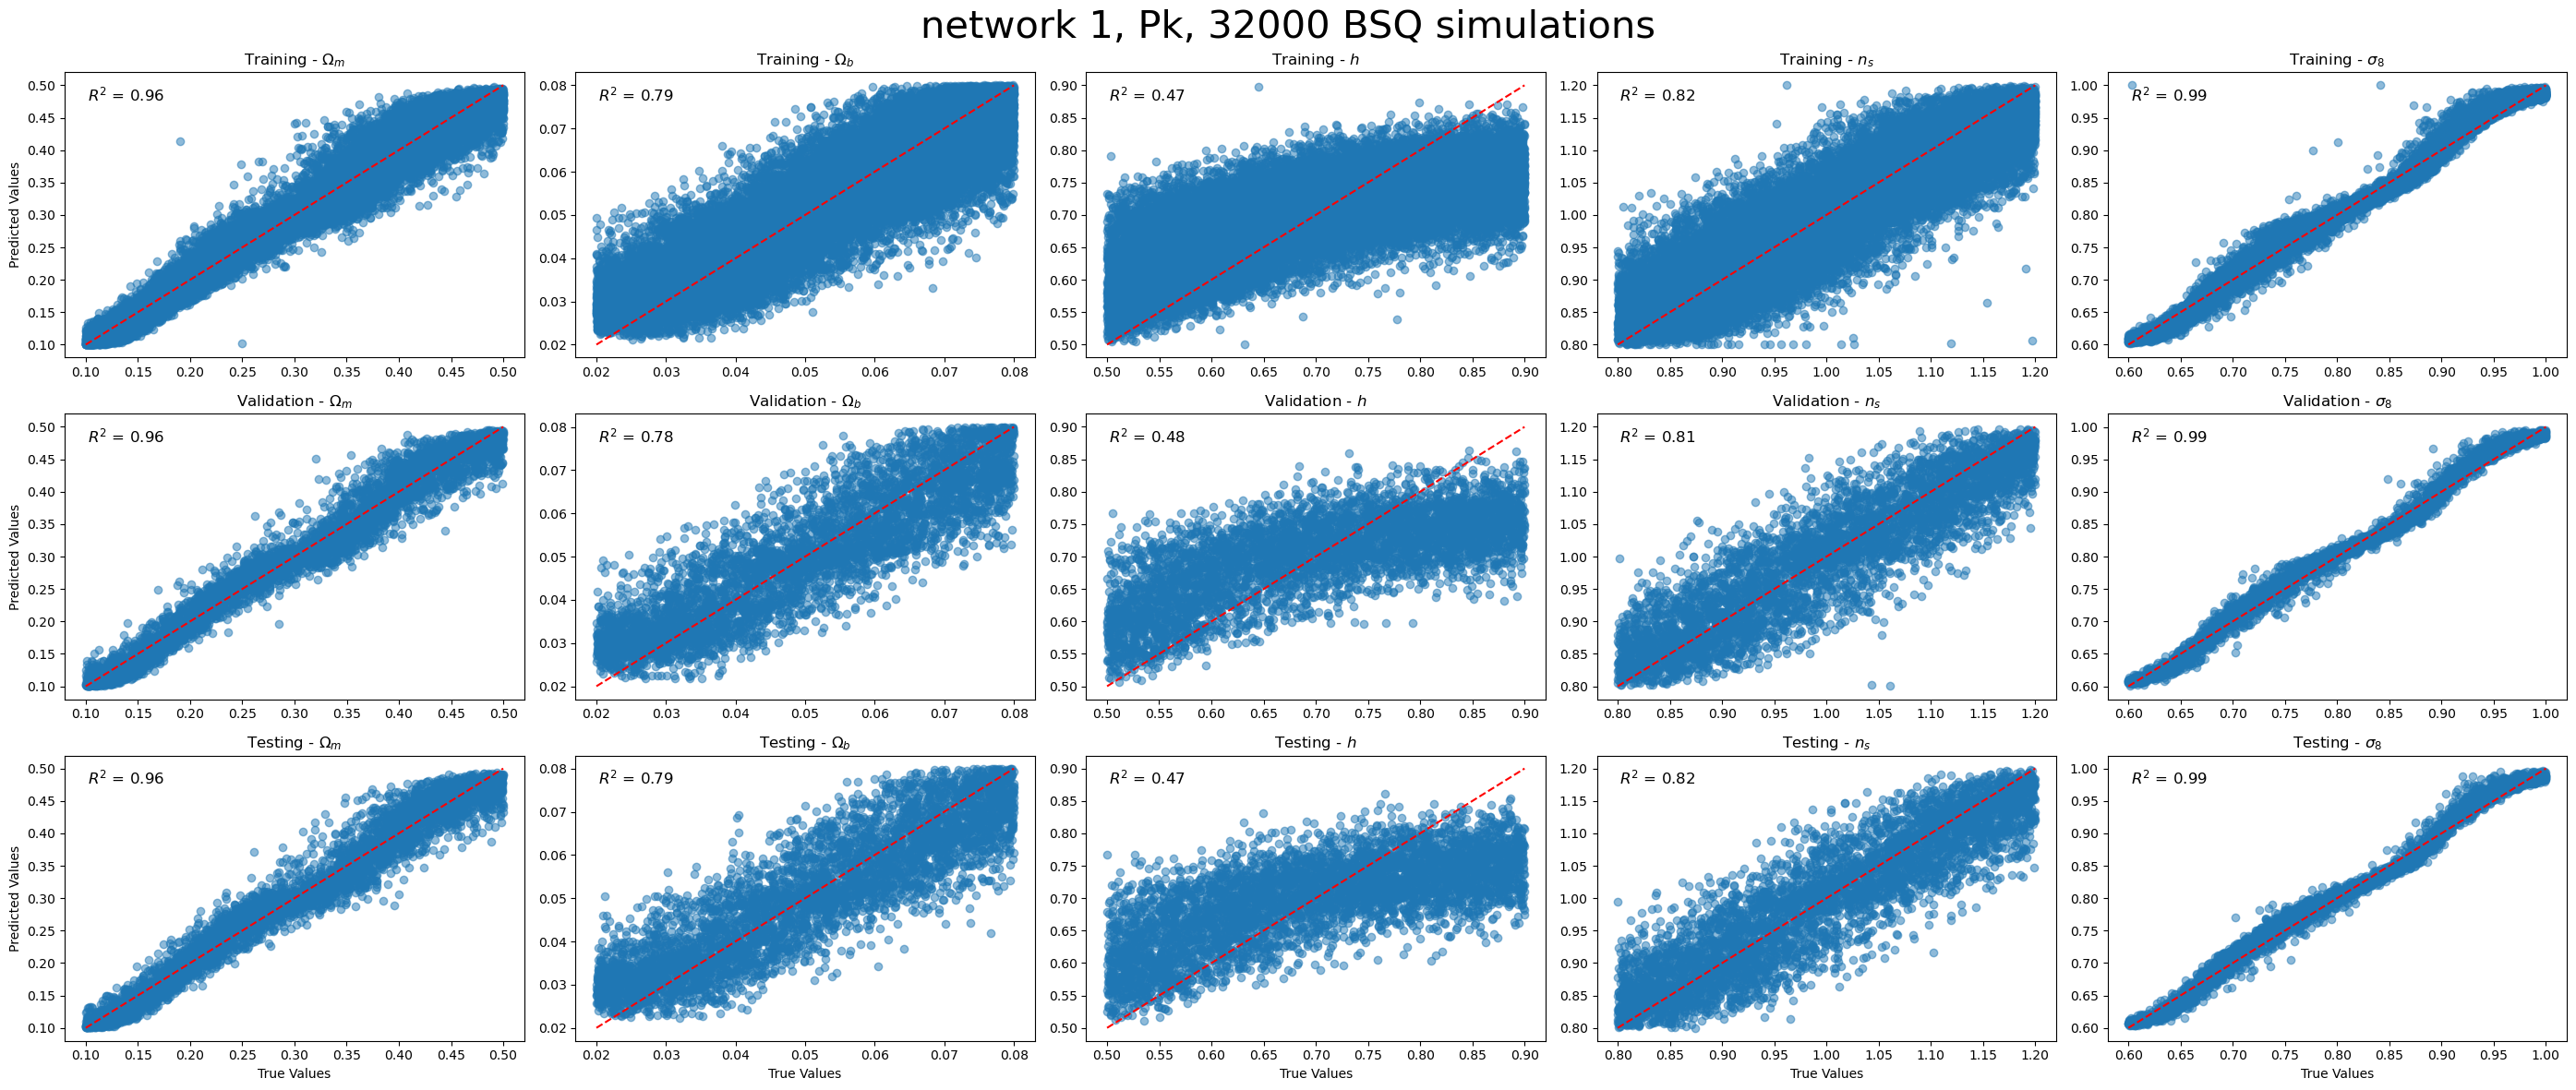

In [31]:
from sklearn.metrics import mean_squared_error
datasets = [('Training', train_predicted, train_true), 
            ('Validation', valid_predicted, valid_true), 
            ('Testing', test_predicted, test_true)]

fig, axes = plt.subplots(3, num_params, figsize=(28, 12))

for row, (dataset_name, preds, truths) in enumerate(datasets):
    for col in range(num_params):
        ax = axes[row, col]
        ax.scatter(truths[:, col], preds[:, col], alpha=0.5)
        ax.plot([truths[:, col].min(), truths[:, col].max()], [truths[:, col].min(), truths[:, col].max()], 'r--')
        ax.set_title(f'{dataset_name} - {param_names[col]}')
        axes[2][col].set_xlabel('True Values')
        axes[row][0].set_ylabel('Predicted Values')
        r2 = r2_score(truths[:, col], preds[:, col])
        mse = mean_squared_error(truths[:, col], preds[:, col])
        ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=12)
        # ax.text(0.05, 0.9, f'$mse$ = {mse:.2f}', transform=ax.transAxes, fontsize=12)
plt.suptitle(r'network 1, Pk, 32000 BSQ simulations', size = 30)
plt.tight_layout()
# plt.savefig('transfer10_network2_Pk_1000_LC_32000_BSQ.png')
plt.show()
